# Notebook 04: Quality Assessment Framework

This notebook computes composite quality indices from the 31 verification metrics
produced by notebook `03_measuring_performances`. It implements a three-tier
quality assessment for each of the 9 reference-vs-test combinations
({CPC, IMERGL, IMERGF} × {LS, LSEQM, LSEQM+DL}).

### Three-tier quality components

| Component | Weight | Inputs |
|-----------|--------|--------|
| **Basic Statistical Quality (BSQS)** | 0.35 | RB (0.30), RMSE (0.30), NSE (0.40) |
| **Distribution Quality (DQS)** | 0.35 | Extreme pctls (0.45), General pctls (0.25), Variability (0.15), KS (0.15) |
| **Temporal Quality (TQS)** | 0.30 | CSI (0.40), Event timing (0.30), Spell preservation (0.30) |

### Composite outputs

| Variable | Description | Range |
|----------|-------------|-------|
| `continuous_quality` | CQI = 0.35·BSQS + 0.35·DQS + 0.30·TQS | [0, 1] |
| `categorical_quality` | Poor (<0.4), Fair (0.4–0.6), Good (0.6–0.8), Excellent (≥0.8) | 1–4 |
| `confidence_level` | Reliability of the assessment | [0, 1] |

### Two output modes

- **Single dekad** (Step 3): All years pooled, dims = (lat, lon).
- **Timeseries** (Step 4): One quality grid per year, dims = (time, lat, lon).

### References

- WMO (2017), Guidelines on the Calculation of Climate Normals.
- Gupta, H. V. et al. (2009), Decomposition of the mean squared error and NSE performance criteria.
- Wilks, D.S. (2011), Statistical Methods in the Atmospheric Sciences, 3rd ed.

::: {.callout-note title="What you'll do in this notebook"}
nb03 produced 31 separate metrics - too many to read at a glance. This notebook **collapses them into one number per pixel**: the Continuous Quality Index (CQI), a weighted blend of three component scores (basic statistical 0.4, distribution 0.3, temporal 0.3).

**The mental model**: 31 metrics -> 3 components -> 1 CQI. A single map you can scan to see where each method does well.

**Runtime**: about **1 minute** per Bali dekad; the batch cell does all 36 in roughly **3 minutes**.

**Concept reference**: [QA Framework](https://bennyistanto.github.io/hybrid-bias-correction/tutorials/qa-framework.html) explains the weights, the three components, and how to read the maps.
:::


## 1 Connect Google Drive (Colab only)

This section is only required when running in **Google Colab** and your project/data are stored in Google Drive.

- Mounting Drive makes your repository and datasets accessible under `/content/drive`.
- If you run this notebook locally (Jupyter / VS Code), **skip this section**.

**Expected structure (Drive)**
After mounting, your project root should contain:
- `notebooks/`
- `src/`
- `config.yml` (or `config.yaml`)

Proceed to the code cell below to mount Drive.

In [11]:
from google.colab import drive
import os

# Check if the drive is mounted
if os.path.exists('/content/drive'):
    # Try to unmount
    try:
        drive.flush_and_unmount()
        print("Successfully unmounted")
    except:
        print("Unmount failed, the drive might not be mounted or busy")

# Mount the drive
drive.mount('/content/drive')

Successfully unmounted
Mounted at /content/drive


**Troubleshooting:**  
- If Colab becomes disconnected, Reconnect the runtime and rerun the mounting cell.
- If we receive an error such as `Mountpoint must not already contain files`, delete all the sub-folders under "/content/drive" from the Files panel before retrying. We need to delete these one by one starting from the innermost folders, until the last "drive" folder is deleted.

## 2 Install packages (only if needed)

In most cases, **Google Colab already includes the packages required** for this workflow. The most common missing dependency is **`netCDF4`** (NetCDF I/O support).

### Check what is already installed (Colab)
Before installing anything, you can inspect the current environment by running `!pip list`.

- If all required packages are present and only `netCDF4` is missing, install **only `netCDF4`**.
- If other required packages are missing from `!pip list`, install them **together with** `netCDF4` in the code cell below.

### Local Jupyter note
If you are running in a **local environment** (Jupyter / VS Code), assume all dependencies were installed when preparing the environment following the **main repository README**. In that case, you can skip this section.

Proceed to the code cell below only when installation is necessary.

In [12]:
# In Google Colab, almost all packages already available, except netCDF4
!pip install netCDF4

## 3 Calculating Quality

This section computes **composite quality indices** from the 31 verification metrics produced by notebook 03. For each of the 9 reference-vs-test combinations, three component scores (basic statistical, distribution, and temporal) are combined into a Continuous Quality Index (CQI) and a categorical classification (Poor/Fair/Good/Excellent).

Two output modes are produced:
- **Single dekad (aggregated):** pools all years into one spatial quality grid per combination.
- **Timeseries (per-year):** preserves a yearly time axis to track quality evolution.

All outputs are saved as CF-1.8 NetCDF files in method-specific quality folders and feed directly into notebook 05 for visualization.

---

### Step 1: Environment Setup

Add the project root to the Python path so that the `src` package can be imported. Configuration is loaded from `config.yml` using `initialize_config()`.

**Note:** On Windows with conda, DLL directories are registered automatically to avoid `ImportError` issues.

In [13]:
# Setup: Add project root to Python path
import os
import sys
import importlib

# ---------------------------------------------------------------------------
# Windows DLL fix for conda environments
# ---------------------------------------------------------------------------
if sys.platform == 'win32':
    _conda_prefix = os.environ.get('CONDA_PREFIX') or sys.prefix
    _dll_dirs = [
        os.path.join(_conda_prefix, 'Library', 'bin'),
        os.path.join(_conda_prefix, 'Library', 'lib'),
        os.path.join(_conda_prefix, 'Library', 'mingw-w64', 'bin'),
        os.path.join(_conda_prefix, 'bin'),
        _conda_prefix,
    ]
    for _d in _dll_dirs:
        if os.path.isdir(_d):
            try:
                os.add_dll_directory(_d)
            except OSError:
                pass
            if _d not in os.environ.get('PATH', ''):
                os.environ['PATH'] = _d + os.pathsep + os.environ.get('PATH', '')
    del _conda_prefix, _dll_dirs, _d

# ---------------------------------------------------------------------------
# Project root — hardcoded for local Jupyter.
# Change this path to match your local project location.
# ---------------------------------------------------------------------------

# ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
ROOT = '/content/drive/MyDrive/hybrid-bias-correction'
assert os.path.isfile(os.path.join(ROOT, 'src', 'config.py')), f"Not found: {ROOT}"

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

for m in [k for k in sys.modules if k.startswith('src')]:
    del sys.modules[m]

# Initialize configuration from config.yml
import src.config as _cfg
importlib.reload(_cfg)
# ===========================================================================
# AOI config selector
#   'config.yml'      -> full Indonesia (Zenodo input/output bundle)
#   'config_bali.yml' -> Bali example (ships with the repo, ~11 MB)
# Edit this single line to switch the entire pipeline between the two.
# ===========================================================================
CONFIG_FILE = 'config_bali.yml'

_cfg.initialize_config(os.path.join(ROOT, CONFIG_FILE))

from src import config

print(f"Project root: {ROOT}")
print(f"CPC file:     {config.cpc_file}")
print(f"IMERGL file:  {config.imergl_file}")
print(f"IMERGF file:  {config.imergf_file}")
print(f"NetCDF engine: {config.NETCDF_ENGINE}")
print(f"Metrics path: {config.metrics_path_template}")


2026-05-22 02:28:18,797 - INFO - Loaded configuration from /content/drive/MyDrive/hybrid-bias-correction/config_bali.yml
2026-05-22 02:28:18,805 - INFO - Configured main_dir '/content/hybrid-bias-correction' does not exist on this system. Using auto-detected project root: /content/drive/MyDrive/hybrid-bias-correction
2026-05-22 02:28:18,821 - INFO - Configuration initialized successfully.
2026-05-22 02:28:18,822 - INFO -   Main directory: /content/drive/MyDrive/hybrid-bias-correction
2026-05-22 02:28:18,827 - INFO -   Input directory: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali
2026-05-22 02:28:18,833 - INFO -   Output directory: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output
2026-05-22 02:28:18,834 - INFO -   Interactive mode: False
Project root: /content/drive/MyDrive/hybrid-bias-correction
CPC file:     /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_cpcuni.nc4
IMERGL file:  /content/drive/MyDrive/hybrid-bias-correctio

### Step 2: User Inputs

Select the month (1–12) and dekad (1, 2, or 3) for which to compute quality assessment.

In [14]:
# ==============================================================
# Step 2: Gather User Inputs
# ==============================================================

month_input = input('Enter the month (1-12): ').strip()
dekad_input = input('Enter the dekad (1, 2, or 3): ').strip()

try:
    month = int(month_input)
    assert 1 <= month <= 12
except (ValueError, AssertionError):
    raise SystemExit('Invalid month. Please provide a number from 1 to 12.')

try:
    dekad = int(dekad_input)
    assert dekad in (1, 2, 3)
except (ValueError, AssertionError):
    raise SystemExit('Invalid dekad. Must be 1, 2, or 3.')

print(f'\nSelected: month={month}, dekad={dekad}')

Enter the month (1-12): 1
Enter the dekad (1, 2, or 3): 1

Selected: month=1, dekad=1


### Step 3: Single Dekad Quality Assessment

Pool all years and compute one composite quality grid per (reference, method) combination, collapsing the temporal dimension into a single spatial CQI map.

::: {.callout-tip title="What you should see"}
Each pixel now carries one CQI in `[0, 1]` plus its three component scores. A useful check: the **distribution** component should rise noticeably from LS to LSEQM (that is what EQM fixes), while the **basic statistical** component - which includes correlation - barely moves. This split is the single most important thing the QA framework reveals, and it is why the headline CQI does not always favour LSEQM+DL ([why](https://bennyistanto.github.io/hybrid-bias-correction/case-studies/indonesia.html#spatial-skill)).
:::


In [15]:
# ==============================================================
# Step 3: Compute Single Dekad Quality Assessment
# ==============================================================

from src.qa_framework import run_qa_pipeline

sd_files = run_qa_pipeline(month, dekad, mode='single')

print(f'\nSingle dekad quality output files:')
for f in sd_files:
    if f is not None:
        print(f'  {os.path.basename(f)}')

2026-05-22 02:28:28,693 - INFO - [1/9] cpc vs imergl_ls (single)
2026-05-22 02:28:28,772 - INFO - File /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_ls/bali_cli_qualitysd_cpc_imergl_ls_month01_dekad01.nc4 already exists.
2026-05-22 02:28:28,772 - INFO - Non-interactive mode: using 'skip' for existing files
2026-05-22 02:28:28,774 - INFO - Skipping /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_ls/bali_cli_qualitysd_cpc_imergl_ls_month01_dekad01.nc4
2026-05-22 02:28:28,778 - INFO -   Done: bali_cli_qualitysd_cpc_imergl_ls_month01_dekad01.nc4
2026-05-22 02:28:28,781 - INFO - [2/9] cpc vs imergl_lseqm (single)
2026-05-22 02:28:28,860 - INFO - File /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_lseqm/bali_cli_qualitysd_cpc_imergl_lseqm_month01_dekad01.nc4 already exists.
2026-05-22 02:28:28,860 - INFO - Skipping /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_lseq

### Step 4: Timeseries Quality Assessment

For each year in the metrics data, compute quality scores across the dekad window. One quality grid per year, so you can track stability over time.

::: {.callout-tip title="What you should see"}
Expect the per-year CQI to wobble around the pooled value from Step 3 without any single year collapsing to zero. A steadily declining or rising CQI across years would hint at a non-stationarity in the input record (e.g. a sensor change) - not something the Bali bundle should show.
:::


In [16]:
# ==============================================================
# Step 4: Compute Timeseries Quality Assessment
# ==============================================================

ts_files = run_qa_pipeline(month, dekad, mode='timeseries')

print(f'\nTimeseries quality output files:')
for f in ts_files:
    if f is not None:
        print(f'  {os.path.basename(f)}')

2026-05-22 02:28:32,955 - INFO - [1/9] cpc vs imergl_ls (timeseries)
2026-05-22 02:28:33,046 - INFO - File /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_ls/bali_cli_qualityts_cpc_imergl_ls_month01_dekad01.nc4 already exists.
2026-05-22 02:28:33,047 - INFO - Skipping /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_ls/bali_cli_qualityts_cpc_imergl_ls_month01_dekad01.nc4
2026-05-22 02:28:33,053 - INFO -   Done: bali_cli_qualityts_cpc_imergl_ls_month01_dekad01.nc4
2026-05-22 02:28:33,056 - INFO - [2/9] cpc vs imergl_lseqm (timeseries)
2026-05-22 02:28:33,154 - INFO - File /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_lseqm/bali_cli_qualityts_cpc_imergl_lseqm_month01_dekad01.nc4 already exists.
2026-05-22 02:28:33,155 - INFO - Skipping /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_lseqm/bali_cli_qualityts_cpc_imergl_lseqm_month01_dekad01.nc4
2026-05-22 02:28:33,1

### Step 5: Inspect Results

Load one of the output files and visualise the Continuous Quality Index (CQI) to verify correctness.

::: {.callout-tip title="What you should see"}
CQI lies in **[0, 1]** on the categorical bands from the QA tutorial (>=0.80 excellent, >=0.60 good, >=0.40 fair, <0.40 poor). For Bali, dekad 1 of January, median CQI should land in the **0.4 to 0.6** range for LSEQM and LSEQM+DL. Do not be alarmed if LS scores **as high or higher** than LSEQM+DL on the composite index - that is the honest, documented behaviour of CQI, which weights timing-sensitive metrics the correction cannot move. CQI near 1.0 across the whole AOI for a tropical dekad is the suspicious case (wrong file).
:::


File: bali_cli_qualitysd_cpc_imergl_lseqmdl_month01_dekad01.nc4
Variables (6): ['basic_statistical_quality', 'distribution_quality', 'temporal_quality', 'continuous_quality', 'categorical_quality', 'confidence_level']
Dimensions: {'lat': 9, 'lon': 14}


/tmp/ipykernel_2035/1002774415.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'Dimensions: {dict(ds.dims)}')


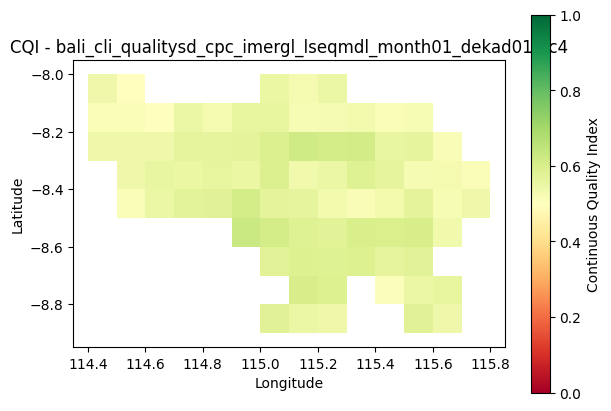

CQI: mean=0.5571, median=0.5536, % Excellent (>=0.8): 0.0%

Categorical breakdown:
  Poor: 0.0%
  Fair: 88.8%
  Good: 11.2%
  Excellent: 0.0%


In [18]:
# ==============================================================
# Step 5: Inspect a Sample Result
# ==============================================================

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Pick the first available single-dekad file (prefer LSEQMDL)
sample_file = None
for f in sd_files:
    if f is not None and os.path.isfile(f):
        sample_file = f
        if 'lseqmdl' in f:
            break

if sample_file is not None:
    ds = xr.open_dataset(sample_file, engine=config.NETCDF_ENGINE)
    print(f'File: {os.path.basename(sample_file)}')
    print(f'Variables ({len(ds.data_vars)}): {list(ds.data_vars)}')
    print(f'Dimensions: {dict(ds.dims)}')

    # Map extent: read from config.AOI_{LON,LAT}_RANGE with MAP_EXTENT_PAD,
    # fall back to the data's own coordinate range if the config is unset.
    pad = float(getattr(config, 'MAP_EXTENT_PAD', 0.1))
    aoi_lon = getattr(config, 'AOI_LON_RANGE', None)
    aoi_lat = getattr(config, 'AOI_LAT_RANGE', None)

    # Plot CQI spatial map
    if 'continuous_quality' in ds.data_vars:
        cqi = ds['continuous_quality']
        if 'time' in cqi.dims:
            cqi = cqi.isel(time=-1)

        xlim = (aoi_lon[0] - pad, aoi_lon[1] + pad) if aoi_lon else (float(cqi.lon.min()), float(cqi.lon.max()))
        ylim = (aoi_lat[0] - pad, aoi_lat[1] + pad) if aoi_lat else (float(cqi.lat.min()), float(cqi.lat.max()))

        # Aspect-correct figure size so the panel matches the AOI shape
        aspect = (xlim[1] - xlim[0]) / max(ylim[1] - ylim[0], 1e-6)
        fig, ax = plt.subplots(figsize=(min(10, 4 * aspect), 4), constrained_layout=True)

        im = ax.pcolormesh(
            cqi.lon, cqi.lat, cqi.values,
            cmap='RdYlGn', vmin=0, vmax=1, shading='auto'
        )
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_title(f'CQI - {os.path.basename(sample_file)}')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_aspect('equal')
        fig.colorbar(im, ax=ax, label='Continuous Quality Index')
        plt.show()

        vals = cqi.values[~np.isnan(cqi.values)]
        if len(vals) > 0:
            print(f'CQI: mean={np.mean(vals):.4f}, '
                  f'median={np.median(vals):.4f}, '
                  f'% Excellent (>=0.8): {100 * np.mean(vals >= 0.8):.1f}%')

    # Print categorical breakdown
    if 'categorical_quality' in ds.data_vars:
        cat = ds['categorical_quality'].values.ravel()
        cat = cat[cat > 0]  # exclude NoData (-9999)
        if len(cat) > 0:
            labels = {1: 'Poor', 2: 'Fair', 3: 'Good', 4: 'Excellent'}
            print('\nCategorical breakdown:')
            for code, name in labels.items():
                pct = 100 * np.mean(cat == code)
                print(f'  {name}: {pct:.1f}%')

    ds.close()
else:
    print('No output files found. Check that metrics files exist from notebook 03.')

---


## Summary

This notebook computed composite quality indices for 9 reference-vs-test combinations
in two modes (single dekad and timeseries). The output NetCDF files are stored in the
method-specific quality directories:

- `data/output/quality_ls/`
- `data/output/quality_lseqm/`
- `data/output/quality_lseqmdl/`

Each file contains six variables: `basic_statistical_quality`, `distribution_quality`,
`temporal_quality`, `continuous_quality`, `categorical_quality`, and `confidence_level`.

These files feed into notebook `06_qa_visualisation` for spatial maps and summary charts.

---


## Batch Run - All Months and Dekads

Run this cell to compute **both single-dekad and timeseries quality assessments**
for every month×dekad combination (12 × 3 = 36 periods, 9 reference×method
combos each).

Periods where metrics files are missing are skipped automatically.

**Prerequisites - run this cell first (skip Steps 2–5):**

| Cell | Purpose |
|------|---------|
| Step 1 | Environment setup, imports, `config` |

In [ ]:
"""
Batch run - QA pipeline for all 36 month×dekad periods.

Requires: config (from Step 1).
"""
from src.qa_framework import run_qa_pipeline

n_done = 0
n_skip = 0

for _m in range(1, 13):
    for _d in [1, 2, 3]:
        tag = f"month {_m:02d} dekad {_d}"
        print(f"▸ {tag}  ", end="")
        try:
            run_qa_pipeline(_m, _d, mode='single')
            run_qa_pipeline(_m, _d, mode='timeseries')
            n_done += 1
            print("✓")
        except Exception as e:
            n_skip += 1
            print(f"✗ {e}")

print(f"\nBatch complete: {n_done} periods done, {n_skip} skipped.")

▸ month 01 dekad 1  2026-05-20 08:26:16,465 - INFO - [1/9] cpc vs imergl_ls (single)
2026-05-20 08:26:17,598 - INFO - Saved quality assessment to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_ls/bali_cli_qualitysd_cpc_imergl_ls_month01_dekad01.nc4
2026-05-20 08:26:17,602 - INFO -   Done: bali_cli_qualitysd_cpc_imergl_ls_month01_dekad01.nc4
2026-05-20 08:26:18,618 - INFO - [2/9] cpc vs imergl_lseqm (single)
2026-05-20 08:26:19,116 - INFO - Saved quality assessment to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_lseqm/bali_cli_qualitysd_cpc_imergl_lseqm_month01_dekad01.nc4
2026-05-20 08:26:19,119 - INFO -   Done: bali_cli_qualitysd_cpc_imergl_lseqm_month01_dekad01.nc4
2026-05-20 08:26:19,821 - INFO - [3/9] cpc vs imergl_lseqmdl (single)
2026-05-20 08:26:20,355 - INFO - Saved quality assessment to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_lseqmdl/bali_cli_qualitysd_cpc_imergl_lseqmdl_mo

---

## End of Code